<a href="https://colab.research.google.com/github/ananyasrivastava2609/Aspect-Based-Sentiment-Analysis-/blob/main/04_BERT_absanlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 102.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

# 1. Check for the Colab GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}") # This should now say "cuda"!

# 2. Load the data (Updated path for Colab)
df = pd.read_csv('/content/cleaned_train.csv').dropna()

# 3. Format the Context for BERT
df['input_text'] = df['text'] + " [SEP] " + df['aspect']

# 4. Map labels and Split
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

X_train_texts, X_val_texts, y_train_labels, y_val_labels = train_test_split(
    df['input_text'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Data loaded and split perfectly!")

Using device: cuda
Data loaded and split perfectly!


In [3]:
# DistilBERT has its own specific vocabulary and tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Convert the text into numerical arrays (with padding and truncation)
# max_length=128 is plenty for restaurant reviews
train_encodings = tokenizer(list(X_train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(X_val_texts), truncation=True, padding=True, max_length=128)

print("Text successfully converted to BERT tokens!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Text successfully converted to BERT tokens!


In [4]:
# Wrap our encodings and labels into a PyTorch Dataset
class ABSADataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ABSADataset(train_encodings, y_train_labels)
val_dataset = ABSADataset(val_encodings, y_val_labels)

print(f"Datasets ready! Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

Datasets ready! Train size: 2881, Val size: 721


In [5]:
# 1. Load the pre-trained STANDARD DISTILBERT, telling it we have 3 sentiment classes
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)

# 2. Define the training rules (UPDATED)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

# 3. Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

print("Starting training... Watch the loss drop!")
trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting training... Watch the loss drop!


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=724, training_loss=0.4831257551414532, metrics={'train_runtime': 127.0196, 'train_samples_per_second': 90.726, 'train_steps_per_second': 5.7, 'total_flos': 274307617960416.0, 'train_loss': 0.4831257551414532, 'epoch': 4.0})

In [6]:
# Get predictions on the validation set
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

target_names = ['negative', 'neutral', 'positive']

print("--- DistilBERT Final Classification Report ---")
print(classification_report(y_val_labels, y_pred, target_names=target_names))
print(f"Final Validation Accuracy: {accuracy_score(y_val_labels, y_pred):.2%}")

--- DistilBERT Final Classification Report ---
              precision    recall  f1-score   support

    negative       0.68      0.68      0.68       161
     neutral       0.55      0.43      0.48       127
    positive       0.86      0.91      0.88       433

    accuracy                           0.78       721
   macro avg       0.70      0.67      0.68       721
weighted avg       0.76      0.78      0.77       721

Final Validation Accuracy: 77.53%


In [7]:
#weighted distilbert
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
from transformers import Trainer, TrainingArguments

# 1. Calculate the Class Weights mathematically
# This gives higher weights to 'neutral' and 'negative', and lower to 'positive'
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Convert to a PyTorch Tensor
weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f"Calculated Class Weights: {weights_tensor}")

# 2. Create a Custom Trainer to inject the weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Extract the labels
        labels = inputs.pop("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits

        # Apply the weights to the CrossEntropyLoss function
        # .to(model.device) ensures the weights are on the GPU alongside the model
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 3. Load a FRESH pre-trained model (so it forgets the previous training)
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)

# 4. Training Arguments
training_args = TrainingArguments(
    output_dir='./results_weighted',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

# 5. Initialize our CUSTOM Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

print("Starting Weighted Training...")
trainer.train()

Calculated Class Weights: tensor([1.4912, 1.8979, 0.5548])


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Weighted Training...


Epoch,Training Loss,Validation Loss
1,0.868487,0.764320
2,0.619207,0.713064
3,0.484734,0.751754
4,0.355921,0.763371


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=724, training_loss=0.5820871216157524, metrics={'train_runtime': 129.691, 'train_samples_per_second': 88.857, 'train_steps_per_second': 5.583, 'total_flos': 274307617960416.0, 'train_loss': 0.5820871216157524, 'epoch': 4.0})

In [8]:
# Get predictions on the validation set
predictions = trainer.predict(val_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

target_names = ['negative', 'neutral', 'positive']

print("--- DistilBERT Final Classification Report ---")
print(classification_report(y_val_labels, y_pred, target_names=target_names))
print(f"Final Validation Accuracy: {accuracy_score(y_val_labels, y_pred):.2%}")

--- DistilBERT Final Classification Report ---
              precision    recall  f1-score   support

    negative       0.61      0.71      0.65       161
     neutral       0.49      0.47      0.48       127
    positive       0.89      0.84      0.86       433

    accuracy                           0.75       721
   macro avg       0.66      0.67      0.67       721
weighted avg       0.75      0.75      0.75       721

Final Validation Accuracy: 74.62%


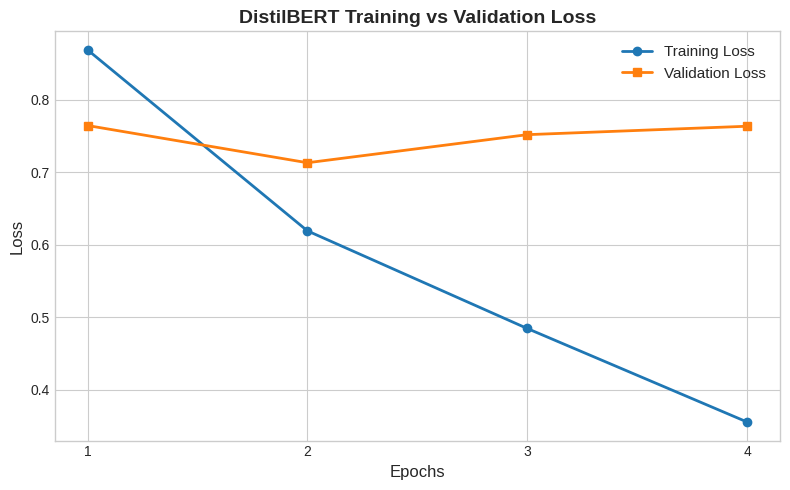

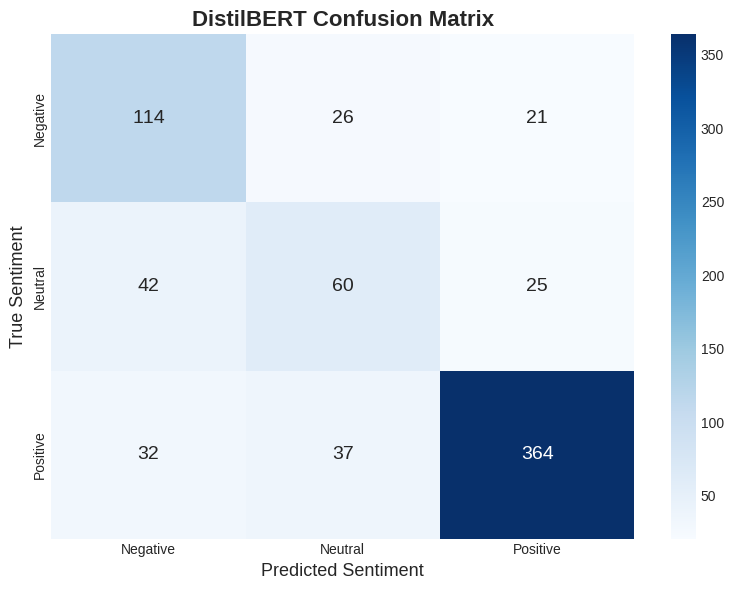

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set a clean, professional style for the report
plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------
# GRAPH 1: Learning Curves (Training vs Validation Loss)
# ---------------------------------------------------------
# Extract loss history from the Hugging Face Trainer
log_history = trainer.state.log_history
train_loss = [log['loss'] for log in log_history if 'loss' in log]
val_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]

# Create epochs list (1 to 4)
epochs = range(1, len(val_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss[:len(val_loss)], label='Training Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s')

plt.title('DistilBERT Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=11)
plt.tight_layout()

# Save the high-resolution image
plt.savefig('distilbert_learning_curve.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# GRAPH 2: Confusion Matrix
# ---------------------------------------------------------
# Generate the matrix using your true labels and BERT's predictions
cm = confusion_matrix(y_val_labels, y_pred)
target_names = ['Negative', 'Neutral', 'Positive']

plt.figure(figsize=(8, 6))
# Create a beautiful heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            annot_kws={"size": 14}) # Make the numbers larger for readability

plt.title('DistilBERT Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Sentiment', fontsize=13)
plt.xlabel('Predicted Sentiment', fontsize=13)
plt.tight_layout()

# Save the high-resolution image
plt.savefig('distilbert_confusion_matrix.png', dpi=300)
plt.show()

In [10]:
#Debert
from transformers import DebertaTokenizer, DebertaForSequenceClassification, Trainer, TrainingArguments
import torch
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 1. Use the specific DeBERTa Tokenizer
deberta_tokenizer = DebertaTokenizer.from_pretrained('microsoft/deberta-base')

# Re-tokenize the data for DeBERTa's specific vocabulary
train_encodings_deb = deberta_tokenizer(list(X_train_texts), truncation=True, padding=True, max_length=128)
val_encodings_deb = deberta_tokenizer(list(X_val_texts), truncation=True, padding=True, max_length=128)

# Re-create the datasets using your existing ABSADataset class
train_dataset_deb = ABSADataset(train_encodings_deb, y_train_labels)
val_dataset_deb = ABSADataset(val_encodings_deb, y_val_labels)

# 2. Load the DeBERTa Model
deberta_model = DebertaForSequenceClassification.from_pretrained('microsoft/deberta-base', num_labels=3)

# 3. Training Arguments
deberta_training_args = TrainingArguments(
    output_dir='./results_deberta',
    num_train_epochs=4,
    per_device_train_batch_size=8,   # Lower batch size so the GPU doesn't run out of memory!
    per_device_eval_batch_size=8,
    learning_rate=1e-5,              # Smaller learning rate for this massive model
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

# 4. Initialize the Trainer (Standard, no class weights for the first run)
deberta_trainer = Trainer(
    model=deberta_model,
    args=deberta_training_args,
    train_dataset=train_dataset_deb,
    eval_dataset=val_dataset_deb
)

print("Starting DeBERTa Training... This will take a few minutes!")
deberta_trainer.train()

# 5. Immediate Evaluation
print("\nPredicting with DeBERTa...")
deb_predictions = deberta_trainer.predict(val_dataset_deb)
deb_y_pred = np.argmax(deb_predictions.predictions, axis=1)

target_names = ['negative', 'neutral', 'positive']
print("--- DeBERTa Final Classification Report ---")
print(classification_report(y_val_labels, deb_y_pred, target_names=target_names))
print(f"Final Validation Accuracy: {accuracy_score(y_val_labels, deb_y_pred):.2%}")

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


Predicting with DeBERTa...


--- DeBERTa Final Classification Report ---
              precision    recall  f1-score   support

    negative       0.68      0.68      0.68       161
     neutral       0.47      0.57      0.52       127
    positive       0.90      0.85      0.87       433

    accuracy                           0.76       721
   macro avg       0.68      0.70      0.69       721
weighted avg       0.77      0.76      0.77       721

Final Validation Accuracy: 76.01%


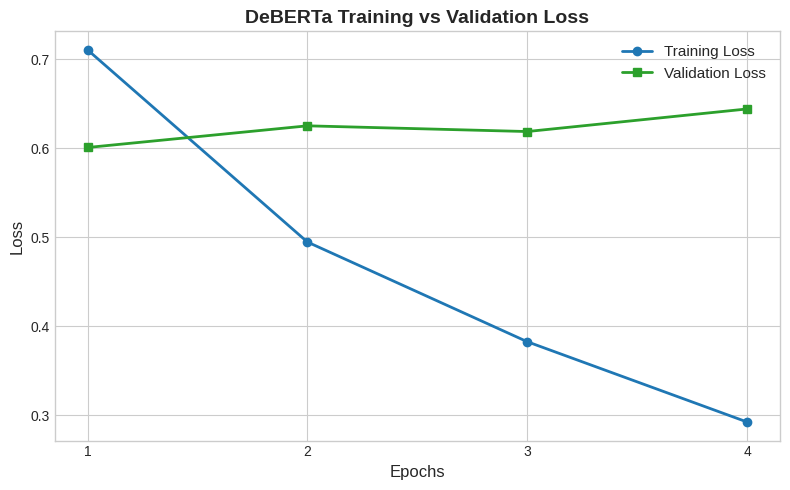

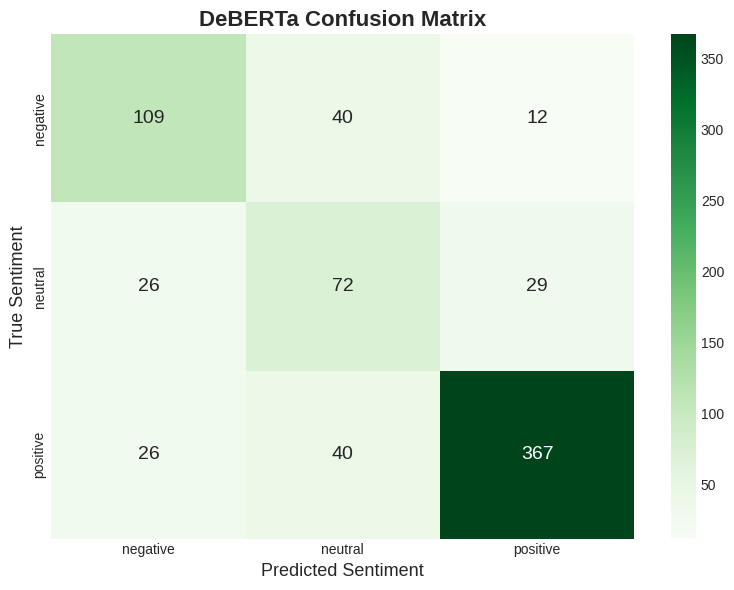

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------
# GRAPH 1: DeBERTa Learning Curves
# ---------------------------------------------------------
log_history_deb = deberta_trainer.state.log_history
train_loss_deb = [log['loss'] for log in log_history_deb if 'loss' in log]
val_loss_deb = [log['eval_loss'] for log in log_history_deb if 'eval_loss' in log]

epochs_deb = range(1, len(val_loss_deb) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_deb, train_loss_deb[:len(val_loss_deb)], label='Training Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(epochs_deb, val_loss_deb, label='Validation Loss', color='#2ca02c', linewidth=2, marker='s') # Using green for DeBERTa

plt.title('DeBERTa Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(epochs_deb)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('deberta_learning_curve.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# GRAPH 2: DeBERTa Confusion Matrix
# ---------------------------------------------------------
cm_deb = confusion_matrix(y_val_labels, deb_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_deb, annot=True, fmt='d', cmap='Greens', # Using green theme to distinguish from DistilBERT
            xticklabels=target_names,
            yticklabels=target_names,
            annot_kws={"size": 14})

plt.title('DeBERTa Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Sentiment', fontsize=13)
plt.xlabel('Predicted Sentiment', fontsize=13)
plt.tight_layout()
plt.savefig('deberta_confusion_matrix.png', dpi=300)
plt.show()

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, matthews_corrcoef

# 1. Get the confusion matrix from your DeBERTa predictions
cm = confusion_matrix(y_val_labels, deb_y_pred)
classes = ['Negative', 'Neutral', 'Positive']

# Initialize dictionaries to store the metrics
metrics = {'Sensitivity': [], 'Specificity': [], 'FPR': [], 'FNR': [], 'NPV': [], 'FDR': []}

# 2. Calculate TP, TN, FP, FN for EACH class individually (One-vs-Rest)
for i in range(len(classes)):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    # Calculate individual metrics (with safe division to avoid zero errors)
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    fpr = FP / (TN + FP) if (TN + FP) != 0 else 0
    fnr = FN / (TP + FN) if (TP + FN) != 0 else 0
    npv = TN / (TN + FN) if (TN + FN) != 0 else 0
    fdr = FP / (FP + TP) if (FP + TP) != 0 else 0

    # Store them
    metrics['Sensitivity'].append(sensitivity)
    metrics['Specificity'].append(specificity)
    metrics['FPR'].append(fpr)
    metrics['FNR'].append(fnr)
    metrics['NPV'].append(npv)
    metrics['FDR'].append(fdr)

# 3. Calculate overall Multiclass MCC (Matthews Correlation Coefficient)
# Scikit-learn has a built-in function that handles multiclass MCC perfectly
mcc = matthews_corrcoef(y_val_labels, deb_y_pred)

# 4. Print the Macro-Averaged results for your final report table
print("--- Advanced Evaluation Measures (DeBERTa Final) ---")
print(f"Sensitivity (Recall): {np.mean(metrics['Sensitivity']):.2f}")
print(f"Specificity: {np.mean(metrics['Specificity']):.2f}")
print(f"False Positive Rate (FPR): {np.mean(metrics['FPR']):.2f}")
print(f"False Negative Rate (FNR): {np.mean(metrics['FNR']):.2f}")
print(f"Negative Predictive Value (NPV): {np.mean(metrics['NPV']):.2f}")
print(f"False Discovery Rate (FDR): {np.mean(metrics['FDR']):.2f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

--- Advanced Evaluation Measures (DeBERTa Final) ---
Sensitivity (Recall): 0.70
Specificity: 0.88
False Positive Rate (FPR): 0.12
False Negative Rate (FNR): 0.30
Negative Predictive Value (NPV): 0.87
False Discovery Rate (FDR): 0.32
Matthews Correlation Coefficient (MCC): 0.58
